In [1]:
# %% [markdown]
# ### Bloque 1: Inicialización y Estructura Base de la PINN

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad numérica
torch.manual_seed(42)
np.random.seed(42)

# Definición de la Red Neuronal Informada por la Física (PINN)
class FokkerPlanckPINN(nn.Module):
    def __init__(self, num_layers=4, num_neurons=60):
        super(FokkerPlanckPINN, self).__init__()
        layers = []
        # Entrada: x (posición) y t (tiempo) -> dimensión 2
        layers.append(nn.Linear(2, num_neurons))
        layers.append(nn.Tanh()) # Tanh nos permite calcular segundas derivadas sin que den cero
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.Tanh())
            
        # Salida: p(x,t) -> dimensión 1 (Probabilidad)
        layers.append(nn.Linear(num_neurons, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

# Definición del potencial físico: Doble Pozo U(x) = x^4 - 2x^2
def U_derivadas(x):
    """Retorna dU/dx y d²U/dx² necesarias para Fokker-Planck"""
    dU_dx = 4 * x**3 - 4 * x
    d2U_dx2 = 12 * x**2 - 4
    return dU_dx, d2U_dx2

print("¡Bloque 1 ejecutado con éxito! Red y Potencial listos.")

¡Bloque 1 ejecutado con éxito! Red y Potencial listos.


In [14]:
# %% [markdown]
# ### Bloque 2: Definición de las Funciones de Pérdida Físicas

# Cálculo determinista de la función de partición Z para anclar la escala de probabilidad
def get_Z(T):
    x_grid = torch.linspace(-2.0, 2.0, 1000).view(-1, 1)
    U, _ = U_derivadas(x_grid)
    U_val = x_grid**4 - 2*x_grid**2
    p_unnorm = torch.exp(-U_val / T)
    dx = 4.0 / 999.0
    return torch.sum(p_unnorm) * dx

def pde_loss(model, x, t, D_bath):
    """Calcula el residuo de la Ecuación de Fokker-Planck"""
    
    p = model(x, t)
    
    # Derivadas de la red
    dp_dt = torch.autograd.grad(p, t, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    dp_dx = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    d2p_dx2 = torch.autograd.grad(dp_dx, x, grad_outputs=torch.ones_like(dp_dx), create_graph=True)[0]
    
    dU_dx, d2U_dx2 = U_derivadas(x)
    
    # Operador diferencial de Fokker-Planck
    fp_operator = (d2U_dx2 * p) + (dU_dx * dp_dx) + (D_bath * d2p_dx2)
    
    residual = dp_dt - fp_operator
    return torch.mean(residual**2)

def distribucion_boltzmann(x, T):
    U = x**4 - 2*x**2
    return torch.exp(-U / T)

def ic_loss(model, x, T_initial):
    """Fuerza la condición inicial real normalizada por la función de partición (Z)"""
    t_cero = torch.zeros_like(x)
    p_pred = model(x, t_cero)
    
    p_real = distribucion_boltzmann(x, T_initial)
    Z = get_Z(T_initial)
    
    # Target inamovible de la densidad normalizada
    p_real_norm = p_real / Z
    
    return torch.mean((p_pred - p_real_norm)**2)

def bc_loss(model, t, D_bath):
    """Fuerza el flujo de probabilidad a ser cero en los límites para conservar masa (Zero-Flux)"""
    x_left = torch.full_like(t, -2.0, requires_grad=True)
    x_right = torch.full_like(t, 2.0, requires_grad=True)
    
    p_left = model(x_left, t)
    p_right = model(x_right, t)
    
    dp_dx_left = torch.autograd.grad(p_left, x_left, grad_outputs=torch.ones_like(p_left), create_graph=True)[0]
    dp_dx_right = torch.autograd.grad(p_right, x_right, grad_outputs=torch.ones_like(p_right), create_graph=True)[0]
    
    dU_dx_left, _ = U_derivadas(x_left)
    dU_dx_right, _ = U_derivadas(x_right)
    
    # Flujo de probabilidad J = dU/dx * p + D_bath * dp/dx
    J_left = dU_dx_left * p_left + D_bath * dp_dx_left
    J_right = dU_dx_right * p_right + D_bath * dp_dx_right
    
    return torch.mean(J_left**2) + torch.mean(J_right**2)

print("¡Bloque 2 ejecutado con éxito! Física y Fronteras acopladas matemáticamente.")

¡Bloque 2 ejecutado con éxito! Física y Fronteras acopladas matemáticamente.


In [15]:
# %% [markdown]
# ### Bloque 3: Entrenamiento del Sistema Caliente (Hot System)

# Parámetros térmicos globales
T_h = 4.0      # Temperatura Inicial Caliente
T_c = 1.5      # Temperatura Inicial Fría
D_bath = 0.4   # Temperatura del baño térmico final (Difusión)

epochs = 2500
lr = 1e-3

# Inicializar y entrenar el modelo Caliente

# Muestreo estocástico espacio-temporal (Collocation Points)
x_col = (torch.rand(1000, 1) * 4.0 - 2.0).requires_grad_(True)
t_col = (torch.rand(1000, 1) * 2.5).requires_grad_(True)
    
model_hot = FokkerPlanckPINN()
optimizer_hot = optim.Adam(model_hot.parameters(), lr=lr)
print(f"Entrenando Sistema Caliente (T_h = {T_h})...")

# Ejemplo para el sistema caliente (aplica los mismos cambios al Bloque 4 del Frío)
for epoch in range(epochs):
    optimizer_hot.zero_grad()
    
    # Collocation Points
    x_col = torch.rand(1000, 1, requires_grad=True) * 4.0 - 2.0 
    t_col = torch.rand(1000, 1, requires_grad=True) * 2.5       
    
    loss_pde = pde_loss(model_hot, x_col, t_col, D_bath)
    loss_ic = ic_loss(model_hot, x_col, T_h)
    loss_bc = bc_loss(model_hot, t_col, D_bath)  # INCLUSIÓN DEL BC_LOSS
    
    loss_total = loss_pde + (15.0 * loss_ic) + (5.0 * loss_bc)
    
    loss_total.backward()
    optimizer_hot.step()

    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Loss: {loss_total.item():.6f} [PDE: {loss_pde.item():.5f}, IC: {loss_ic.item():.5f}]")

print("¡Sistema Caliente entrenado exitosamente!")

Entrenando Sistema Caliente (T_h = 4.0)...
Época    0 | Loss: 53.587231 [PDE: 2.99833, IC: 0.14138]
Época  500 | Loss: 0.515598 [PDE: 0.14756, IC: 0.02215]
Época 1000 | Loss: 0.416796 [PDE: 0.13105, IC: 0.01776]
Época 1500 | Loss: 0.715749 [PDE: 0.15014, IC: 0.01604]
Época 2000 | Loss: 0.378326 [PDE: 0.14286, IC: 0.01521]
¡Sistema Caliente entrenado exitosamente!


In [16]:
# %% [markdown]
# ### Bloque 4: Entrenamiento del Sistema Frío (Cold System)

# Inicializar y entrenar el modelo Frío
# Muestreo estocástico espacio-temporal (Collocation Points)
x_col = (torch.rand(1000, 1) * 4.0 - 2.0).requires_grad_(True)
t_col = (torch.rand(1000, 1) * 2.5).requires_grad_(True)
model_cold = FokkerPlanckPINN()
optimizer_cold = optim.Adam(model_cold.parameters(), lr=lr)
print(f"Entrenando Sistema Frío (T_c = {T_c})...")

# Ejemplo para el sistema caliente (aplica los mismos cambios al Bloque 4 del Frío)
for epoch in range(epochs):
    optimizer_hot.zero_grad()
    
    # Collocation Points
    x_col = torch.rand(1000, 1, requires_grad=True) * 4.0 - 2.0 
    t_col = torch.rand(1000, 1, requires_grad=True) * 2.5       
    
    loss_pde = pde_loss(model_hot, x_col, t_col, D_bath)
    loss_ic = ic_loss(model_hot, x_col, T_h)
    loss_bc = bc_loss(model_hot, t_col, D_bath)  # INCLUSIÓN DEL BC_LOSS
    
    loss_total = loss_pde + (15.0 * loss_ic) + (5.0 * loss_bc)
    
    loss_total.backward()
    optimizer_hot.step()
    
    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Loss: {loss_total.item():.6f} [PDE: {loss_pde.item():.5f}, IC: {loss_ic.item():.5f}]")

print("¡Sistema Frío entrenado exitosamente!")

Entrenando Sistema Frío (T_c = 1.5)...
Época    0 | Loss: 0.345996 [PDE: 0.12829, IC: 0.01418]
Época  500 | Loss: 0.390660 [PDE: 0.15670, IC: 0.01320]
Época 1000 | Loss: 0.334969 [PDE: 0.12633, IC: 0.01345]
Época 1500 | Loss: 0.337002 [PDE: 0.11394, IC: 0.01396]
Época 2000 | Loss: 0.335169 [PDE: 0.11239, IC: 0.01420]
¡Sistema Frío entrenado exitosamente!


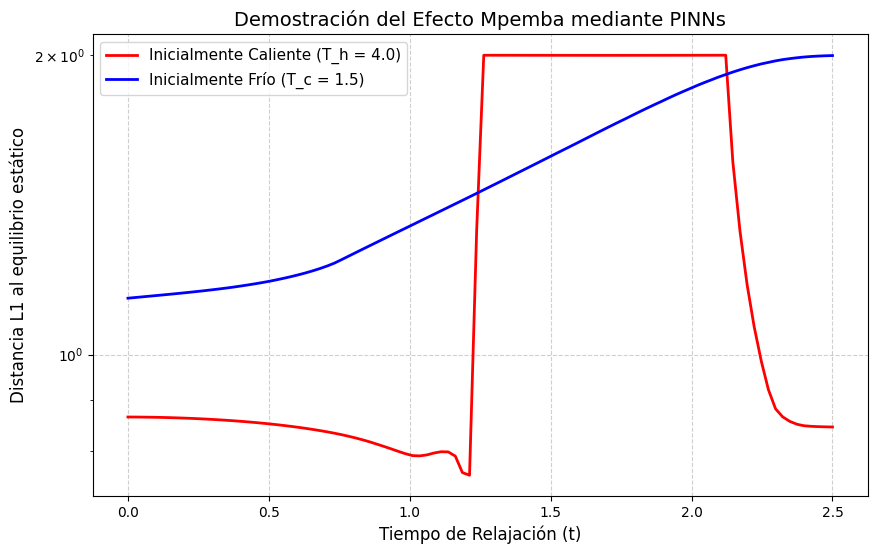

In [17]:
# %% [markdown]
# ### Bloque 5: Análisis del Efecto Mpemba y Generación de Gráficas

tiempos_eval = np.linspace(0.0, 2.5, 100)
x_eval_np = np.linspace(-2.0, 2.0, 200)
dx = x_eval_np[1] - x_eval_np[0]

x_eval_torch = torch.tensor(x_eval_np, dtype=torch.float32).view(-1, 1)

distancias_hot = []
distancias_cold = []

# Distribución de equilibrio del Baño (Target Normalizado)
Z_bath = get_Z(D_bath).item()
p_eq_real = (distribucion_boltzmann(x_eval_torch, D_bath) / Z_bath).detach().numpy().flatten()

for t in tiempos_eval:
    t_torch = torch.full_like(x_eval_torch, t)
    
    p_h_pred = model_hot(x_eval_torch, t_torch).detach().numpy().flatten()
    p_c_pred = model_cold(x_eval_torch, t_torch).detach().numpy().flatten()
    
    # Recorte para no-negatividad
    p_h_pred = np.clip(p_h_pred, a_min=0, a_max=None)
    p_c_pred = np.clip(p_c_pred, a_min=0, a_max=None)
    
    # Normalización espacial rigurosa usando la integral discreta (dx)
    p_h_norm = p_h_pred / (np.sum(p_h_pred) * dx + 1e-8)
    p_c_norm = p_c_pred / (np.sum(p_c_pred) * dx + 1e-8)
    
    # Distancia L1 al equilibrio estático (Preferida por la literatura para el efecto Mpemba)
    dist_h = np.sum(np.abs(p_h_norm - p_eq_real)) * dx
    dist_c = np.sum(np.abs(p_c_norm - p_eq_real)) * dx
    
    distancias_hot.append(dist_h)
    distancias_cold.append(dist_c)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(tiempos_eval, distancias_hot, label=f'Inicialmente Caliente (T_h = {T_h})', color='red', linewidth=2)
plt.plot(tiempos_eval, distancias_cold, label=f'Inicialmente Frío (T_c = {T_c})', color='blue', linewidth=2)

plt.title('Demostración del Efecto Mpemba mediante PINNs', fontsize=14)
plt.xlabel('Tiempo de Relajación (t)', fontsize=12)
plt.ylabel('Distancia L1 al equilibrio estático', fontsize=12)
plt.yscale('log') # Visualización obligatoria para evidenciar el cruce de decaimientos
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

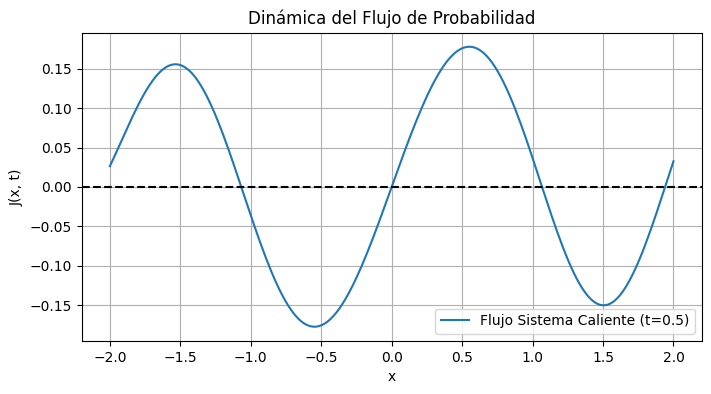

In [21]:
import torch

# 1. Definimos x_eval_torch explícitamente con seguimiento de gradiente
x_eval_torch = torch.tensor(x_eval_np, dtype=torch.float32).view(-1, 1).requires_grad_(True)
t_fix = torch.full_like(x_eval_torch, 0.5)

# 2. Ahora, al calcular el flujo, usamos el modelo en un contexto donde se preserva el grafo
# Aseguramos que la entrada al modelo permita el rastreo
p = model_hot(x_eval_torch, t_fix)

# 3. Calculamos gradientes con create_graph=True para permitir derivadas de orden superior
dp_dx = torch.autograd.grad(p, x_eval_torch, grad_outputs=torch.ones_like(p), create_graph=True)[0]
dU_dx, _ = U_derivadas(x_eval_torch)

# 4. Calculamos el flujo J
j_hot = -(dU_dx * p + D_bath * dp_dx)

# 5. Convertimos a numpy SOLO después de finalizar los cálculos de gradiente
j_hot_np = j_hot.detach().cpu().numpy()

# 6. Graficar
plt.figure(figsize=(8, 4))
plt.plot(x_eval_np, j_hot_np, label='Flujo Sistema Caliente (t=0.5)')
plt.axhline(0, color='black', linestyle='--')
plt.title('Dinámica del Flujo de Probabilidad')
plt.xlabel('x'); plt.ylabel('J(x, t)')
plt.legend(); plt.grid(True)
plt.show()

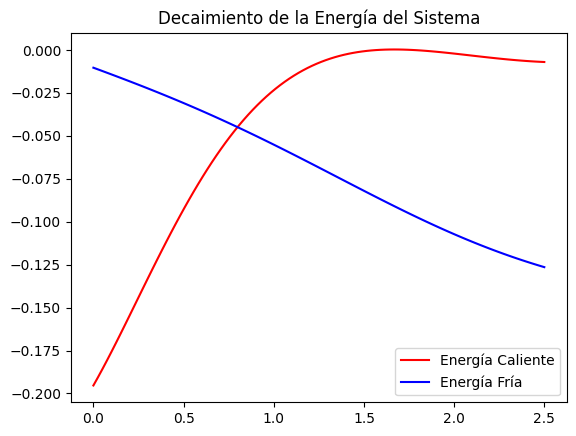

In [19]:
def calcular_energia_libre(model, x, t, T):
    p = model(x, t)
    U_val = x**4 - 2*x**2
    # E = integral(U * p)
    return torch.sum(U_val * p) * dx

# Calcular para comparar ambos sistemas
e_hot = [calcular_energia_libre(model_hot, x_eval_torch, torch.full_like(x_eval_torch, t), D_bath).item() for t in tiempos_eval]
e_cold = [calcular_energia_libre(model_cold, x_eval_torch, torch.full_like(x_eval_torch, t), D_bath).item() for t in tiempos_eval]

plt.plot(tiempos_eval, e_hot, label='Energía Caliente', color='red')
plt.plot(tiempos_eval, e_cold, label='Energía Fría', color='blue')
plt.title('Decaimiento de la Energía del Sistema')
plt.legend(); plt.show()